# Student performance risk assessment

This notebook cleans the student performance data, creates transparent proxy labels for academic and dropout risk, trains several multiclass models, and compares their results. Results are displayed inline.

## Setup

I start by importing the tools used in the analysis and setting a fixed random state so the results can be reproduced.

In [2]:
from pathlib import Path
import json
import warnings
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

from xgboost import XGBClassifier
xgboost_available = True

In [3]:
warnings.filterwarnings('ignore', category=FutureWarning)
RANDOM_STATE = 42
RISK_LEVELS = ['Low', 'Medium', 'High']
DATA_PATH = Path('Student_Performance.csv')
MODEL_EXPORT_DIR = Path('model_exports')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

## Loading the student data

I load the student data and take a first look at its structure before making any changes.

In [4]:
data = pd.read_csv(DATA_PATH)
print(f'Loaded {len(data):,} rows and {data.shape[1]} columns.')

Loaded 25,000 rows and 16 columns.


In [5]:
display(data.head())

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.100,84.300,yes,<15 min,yes,notes,42.700,55.400,57.000,53.100,e
1,2,18,female,public,graduate,3.700,87.800,yes,>60 min,no,textbook,57.600,68.800,64.800,61.300,d
2,3,17,female,private,post graduate,7.900,65.500,no,<15 min,no,notes,84.800,95.000,79.200,89.600,b
3,4,16,other,public,high school,1.100,58.100,no,15-30 min,no,notes,44.400,27.500,54.700,41.600,e
4,5,16,female,public,high school,1.300,61.000,yes,30-60 min,yes,group study,8.900,32.700,30.000,25.400,f


In [6]:
display(data.dtypes.rename('dtype').to_frame())

,dtype
student_id,int64
age,int64
gender,str
school_type,str
parent_education,str
study_hours,float64
attendance_percentage,float64
internet_access,str
travel_time,str
extra_activities,str


In [7]:
display(data.isna().sum().rename('missing_values').to_frame())

,missing_values
student_id,0
age,0
gender,0
school_type,0
parent_education,0
study_hours,0
attendance_percentage,0
internet_access,0
travel_time,0
extra_activities,0


## Cleaning duplicate records

The file contains exact repeated rows. Since every value is identical, these are duplicate records rather than separate observations.

In [8]:
duplicate_count = int(data.duplicated().sum())
data = data.drop_duplicates().reset_index(drop=True)
print(f'Removed {duplicate_count:,} exact duplicate rows.')
print(f'Clean shape: {data.shape}')
print(f'Unique students: {data.student_id.nunique():,}')
assert data.student_id.is_unique
assert not data.isna().any().any()

Removed 10,000 exact duplicate rows.
Clean shape: (15000, 16)
Unique students: 15,000


## Exploring the cleaned data

These summaries and plots show the distributions of the main numeric variables and the original final-grade outcome.

In [9]:
numeric_columns = ['age', 'study_hours', 'attendance_percentage', 'math_score', 'science_score', 'english_score', 'overall_score']
display(data[numeric_columns].describe().T)
display(data['final_grade'].value_counts().sort_index().rename('students').to_frame())

,count,mean,std,min,25%,50%,75%,max
age,15000.000,16.476,1.704,14.000,15.000,16.000,18.000,19.000
study_hours,15000.000,4.259,2.172,0.500,2.400,4.300,6.100,8.000
attendance_percentage,15000.000,74.992,14.401,50.000,62.600,75.000,87.400,100.000
math_score,15000.000,63.775,20.920,0.000,48.200,64.100,80.100,100.000
science_score,15000.000,63.751,21.028,0.000,48.100,64.000,80.100,100.000
english_score,15000.000,63.709,20.860,0.000,48.300,64.200,80.000,100.000
overall_score,15000.000,64.016,18.978,14.500,49.000,64.300,79.100,100.000


,students
final_grade,
a,721
b,1638
c,3697
d,3770
e,3378
f,1796


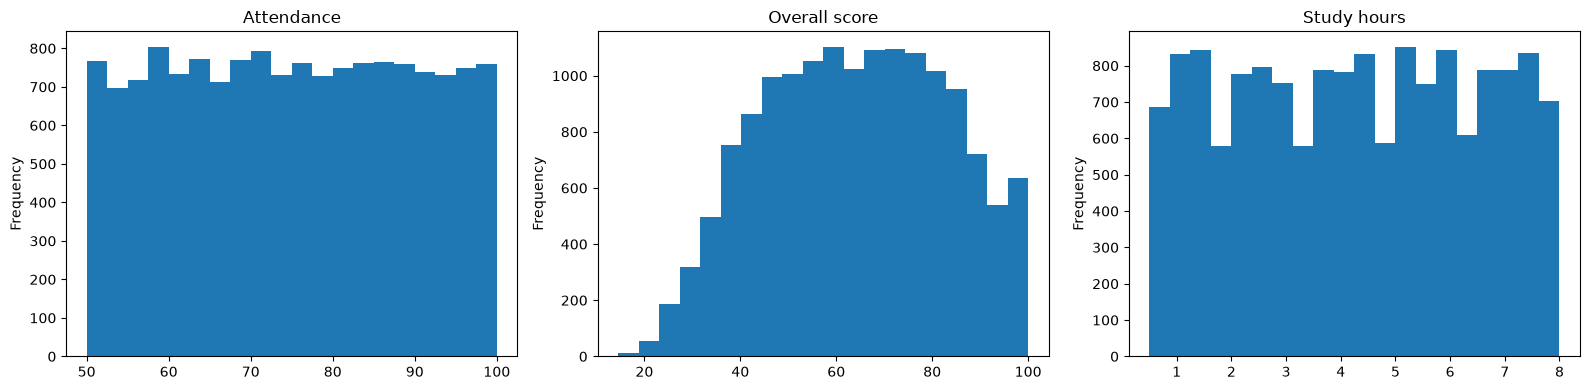

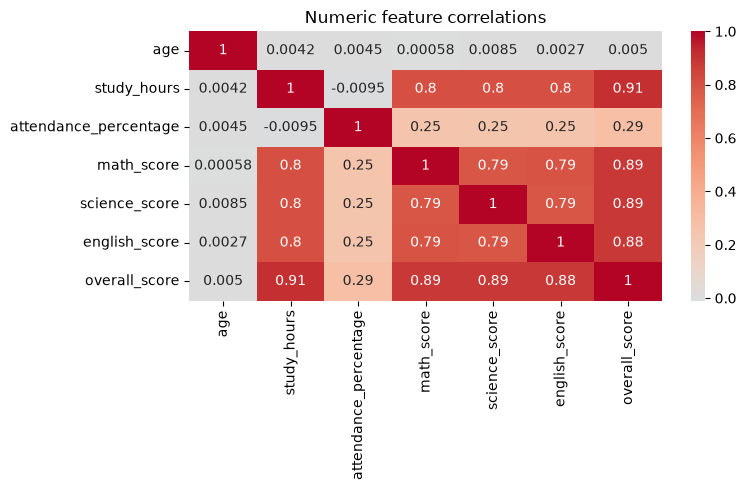

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
data['attendance_percentage'].plot.hist(bins=20, ax=axes[0], title='Attendance')
data['overall_score'].plot.hist(bins=20, ax=axes[1], title='Overall score')
data['study_hours'].plot.hist(bins=20, ax=axes[2], title='Study hours')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.heatmap(data[numeric_columns].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Numeric feature correlations')
plt.tight_layout()
plt.show()

## Creating the academic and dropout risk labels

There is no confirmed dropout outcome in this dataset. Academic risk uses subject performance and study hours. Dropout risk combines attendance, performance, study hours, internet access, travel time, and extracurricular activity.

In [11]:
# Keep the scoring weights separate so the assumptions are easy to explain.
academic_weights = {
    'math_score': 0.35,
    'science_score': 0.30,
    'english_score': 0.25,
    'study_hours': 0.10,
}

dropout_weights = {
    'attendance_risk': 0.45,
    'performance_risk': 0.25,
    'study_hours_risk': 0.10,
    'internet_penalty': 0.10,
    'travel_penalty': 0.05,
    'activity_penalty': 0.05,
}

weights_table = pd.DataFrame({
    'academic_score_weight': pd.Series(academic_weights),
    'dropout_score_weight': pd.Series(dropout_weights),
}).fillna(0)
display(weights_table)

print(f"Academic weights total: {sum(academic_weights.values()):.2f}")
print(f"Dropout weights total: {sum(dropout_weights.values()):.2f}")

,academic_score_weight,dropout_score_weight
activity_penalty,0.000,0.050
attendance_risk,0.000,0.450
english_score,0.250,0.000
internet_penalty,0.000,0.100
math_score,0.350,0.000
performance_risk,0.000,0.250
science_score,0.300,0.000
study_hours,0.100,0.000
study_hours_risk,0.000,0.100
travel_penalty,0.000,0.050


Academic weights total: 1.00
Dropout weights total: 1.00


In [12]:
academic_score = (0.35 * data['math_score'] + 0.30 * data['science_score'] + 0.25 * data['english_score'] + 0.10 * (data['study_hours'] / 8 * 100))
data['academic_risk'] = pd.cut(academic_score, bins=[-float('inf'), 36, 64, float('inf')], labels=['High', 'Medium', 'Low']).astype(str)

performance_risk = 100 - academic_score
internet_penalty = data['internet_access'].eq('no').astype(float) * 20
travel_penalty = data['travel_time'].map({'<15 min': 0, '15-30 min': 5, '30-60 min': 10, '>60 min': 20})
activity_penalty = data['extra_activities'].eq('no').astype(float) * 10
dropout_score = (0.45 * (100 - data['attendance_percentage']) + 0.25 * performance_risk + 0.10 * (100 - data['study_hours'] / 8 * 100) + 0.10 * internet_penalty + 0.05 * travel_penalty + 0.05 * activity_penalty)
data['dropout_risk'] = pd.cut(dropout_score, bins=[-float('inf'), 20, 35, float('inf')], labels=['Low', 'Medium', 'High']).astype(str)

display(data[['academic_risk', 'dropout_risk']].value_counts().rename('students').to_frame())
display(data[['academic_risk', 'dropout_risk']].apply(pd.Series.value_counts).fillna(0).astype(int))

,,students
academic_risk,dropout_risk,
Low,Low,4147
Medium,Medium,3877
Low,Medium,3137
Medium,High,2004
High,High,1289
Medium,Low,276
High,Medium,237
Low,High,33


,academic_risk,dropout_risk
High,1526,3326
Low,7317,4423
Medium,6157,7251


## Choosing features and preparing the data

Identifiers and outcome-like columns are excluded. overall_score and final_grade are not used as features because they would leak performance information into the risk assessment.

In [13]:
numeric_features = ['age', 'study_hours', 'attendance_percentage', 'math_score', 'science_score', 'english_score']
categorical_features = ['gender', 'school_type', 'parent_education', 'internet_access', 'travel_time', 'extra_activities', 'study_method']
feature_columns = numeric_features + categorical_features
target_columns = ['academic_risk', 'dropout_risk']
X = data[feature_columns]

preprocessor = ColumnTransformer([
    ('numeric', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), numeric_features),
    ('categorical', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_features),
])

model_builders = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, min_samples_leaf=20, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=250, max_depth=14, min_samples_leaf=5, class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE),
}
if xgboost_available:
    model_builders['XGBoost'] = XGBClassifier(n_estimators=250, max_depth=5, learning_rate=0.05, subsample=0.85, colsample_bytree=0.85, objective='multi:softprob', eval_metric='mlogloss', tree_method='hist', random_state=RANDOM_STATE, n_jobs=2)

print(f'Using {len(feature_columns)} features.')
print(f'Models to compare: {list(model_builders)}')

Using 13 features.
Models to compare: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']


## Training and evaluating the models

Each target is trained separately with a stratified split. We compare accuracy, balanced accuracy, macro-F1, weighted-F1, and High-risk precision/recall/F1.

In [14]:
all_metrics = []
all_predictions = []
fitted_models = {}

for target in target_columns:
    X_train, X_test, y_train, y_test = train_test_split(X, data[target], test_size=0.20, stratify=data[target], random_state=RANDOM_STATE)
    for model_name, estimator in model_builders.items():
        pipeline = Pipeline([('preprocess', preprocessor), ('model', estimator)])
        fit_target = y_train
        decoder = None
        if model_name == 'XGBoost':
            decoder = {0: 'Low', 1: 'Medium', 2: 'High'}
            fit_target = y_train.map({label: code for code, label in decoder.items()})
        pipeline.fit(X_train, fit_target)
        predictions_for_test = pd.Series(pipeline.predict(X_test), index=y_test.index)
        if decoder:
            predictions_for_test = predictions_for_test.map(decoder)
        report = classification_report(y_test, predictions_for_test, labels=RISK_LEVELS, output_dict=True, zero_division=0)
        high = report['High']
        all_metrics.append({'risk': target, 'model': model_name, 'accuracy': accuracy_score(y_test, predictions_for_test), 'balanced_accuracy': balanced_accuracy_score(y_test, predictions_for_test), 'macro_f1': f1_score(y_test, predictions_for_test, labels=RISK_LEVELS, average='macro'), 'weighted_f1': f1_score(y_test, predictions_for_test, labels=RISK_LEVELS, average='weighted'), 'high_precision': high['precision'], 'high_recall': high['recall'], 'high_f1': high['f1-score']})
        all_predictions.append(pd.DataFrame({'risk': target, 'model': model_name, 'actual': y_test, 'predicted': predictions_for_test}))
        fitted_models[(target, model_name)] = pipeline

metrics = pd.DataFrame(all_metrics)
predictions = pd.concat(all_predictions, ignore_index=True)
display(metrics.sort_values(['risk', 'macro_f1'], ascending=[True, False]).round(3))

,risk,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,high_precision,high_recall,high_f1
0,academic_risk,Logistic Regression,0.990,0.992,0.983,0.990,0.933,1.000,0.965
3,academic_risk,XGBoost,0.985,0.982,0.983,0.985,0.980,0.974,0.977
2,academic_risk,Random Forest,0.969,0.974,0.958,0.969,0.871,0.993,0.928
1,academic_risk,Decision Tree,0.946,0.948,0.929,0.946,0.818,0.961,0.884
4,dropout_risk,Logistic Regression,0.991,0.994,0.991,0.991,0.985,1.000,0.993
7,dropout_risk,XGBoost,0.978,0.974,0.977,0.978,0.989,0.956,0.972
6,dropout_risk,Random Forest,0.953,0.954,0.954,0.953,0.949,0.953,0.951
5,dropout_risk,Decision Tree,0.911,0.918,0.911,0.911,0.879,0.932,0.905


## Looking at the detailed results

The best model for each risk is selected by macro-F1 and then High-risk recall. Confusion matrices show where its predictions differ from the proxy labels.

academic_risk: Logistic Regression
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00      1463
      Medium       1.00      0.98      0.99      1232
        High       0.93      1.00      0.97       305

    accuracy                           0.99      3000
   macro avg       0.98      0.99      0.98      3000
weighted avg       0.99      0.99      0.99      3000



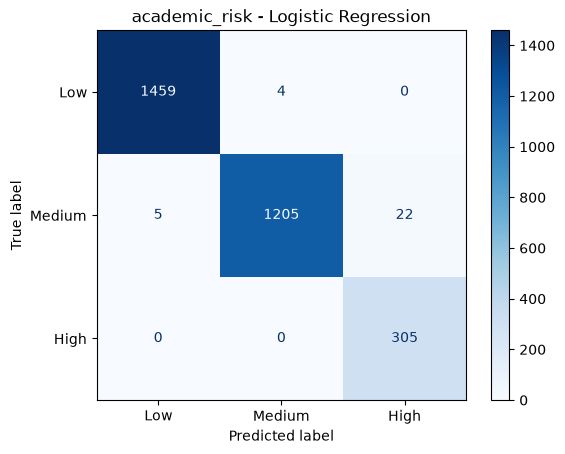

dropout_risk: Logistic Regression
              precision    recall  f1-score   support

         Low       0.98      1.00      0.99       885
      Medium       1.00      0.98      0.99      1450
        High       0.99      1.00      0.99       665

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000



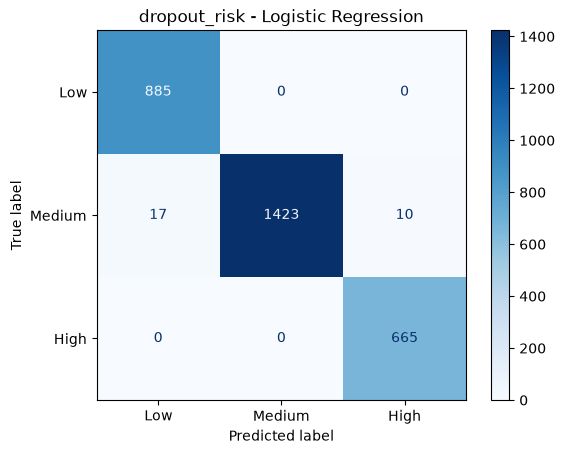

In [15]:
for target in target_columns:
    best_model = metrics[metrics['risk'] == target].sort_values(['macro_f1', 'high_recall'], ascending=False).iloc[0]['model']
    selected = predictions[(predictions['risk'] == target) & (predictions['model'] == best_model)]
    print(f'{target}: {best_model}')
    print(classification_report(selected['actual'], selected['predicted'], labels=RISK_LEVELS, zero_division=0))
    matrix = confusion_matrix(selected['actual'], selected['predicted'], labels=RISK_LEVELS)
    ConfusionMatrixDisplay(matrix, display_labels=RISK_LEVELS).plot(cmap='Blues', values_format='d')
    plt.title(f'{target} - {best_model}')
    plt.show()

## Comparing the features used by each model

Random Forest feature importance is displayed for each target. These values describe model reliance, not causation.

In [16]:
for target in target_columns:
    model = fitted_models[(target, 'Random Forest')]
    names = model.named_steps['preprocess'].get_feature_names_out()
    importance = pd.Series(model.named_steps['model'].feature_importances_, index=names)
    print(target)
    display(importance.sort_values(ascending=False).head(12).rename('importance').to_frame())

academic_risk


,importance
numeric__attendance_percentage,0.356
numeric__math_score,0.183
numeric__science_score,0.159
numeric__english_score,0.151
numeric__study_hours,0.104
numeric__age,0.006
categorical__internet_access_no,0.002
categorical__internet_access_yes,0.002
categorical__extra_activities_yes,0.002
categorical__school_type_public,0.002


dropout_risk


,importance
numeric__attendance_percentage,0.356
numeric__math_score,0.183
numeric__science_score,0.159
numeric__english_score,0.151
numeric__study_hours,0.104
numeric__age,0.006
categorical__internet_access_no,0.002
categorical__internet_access_yes,0.002
categorical__extra_activities_yes,0.002
categorical__school_type_public,0.002


## results
These models demonstrate a risk-screening workflow. High scores simply mean the models are successfully following the scoring rules. A full production rollout would require validating against historical outcomes, checking for fairness, and consulting education specialists.


In [17]:
best_models = metrics.sort_values(['risk', 'macro_f1', 'high_recall'], ascending=[True, False, False]).groupby('risk', as_index=False).first()
display(best_models[['risk', 'model', 'macro_f1', 'high_recall', 'high_f1', 'accuracy']].round(3))

,risk,model,macro_f1,high_recall,high_f1,accuracy
0,academic_risk,Logistic Regression,0.983,1.000,0.965,0.990
1,dropout_risk,Logistic Regression,0.991,1.000,0.993,0.991
